# Customer Churn Prediction using Machine Learning

In this project, I built a machine learning model to predict whether a telecom customer will churn (leave the service) or not.

Customer churn is a common business problem in telecom companies because retaining existing customers is usually cheaper than acquiring new ones.

The goal of this project is to analyze customer data and build predictive models that can help identify customers who are at risk of churning.

## Problem Statement

Telecom companies face significant losses when customers leave their service.

By predicting which customers are likely to churn, companies can take proactive actions such as offering discounts, improving services, or providing personalized support.

The objective of this project is to develop a machine learning model that can predict customer churn based on customer demographics and service usage patterns.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import  LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


from imblearn.over_sampling import SMOTE

import joblib

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Understanding

## Dataset Description

The dataset used in this project is the **Telco Customer Churn dataset**.

It contains information about telecom customers and whether they left the company in the last month.

Dataset overview:

- Total customers: ~7000
- Target variable: **Churn (Yes / No)**

Important features include:

- Tenure (how long the customer has stayed)
- Monthly charges
- Total charges
- Contract type
- Internet service
- Payment method

In [37]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Dataset Cleaning 


In [38]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [116]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

## Exploratory Data Analysis (EDA)

To better understand the dataset, I performed exploratory data analysis.

The main goals were:

- Understand the distribution of churn vs non-churn customers
- Identify patterns between features and churn
- Detect important variables affecting customer churn

Several visualizations were created including:

- Churn distribution
- Contract type vs churn
- Monthly charges vs churn
- Tenure vs churn
- Correlation heatmap

[Text(0.5, 1.0, 'CHURN VS COUNT')]

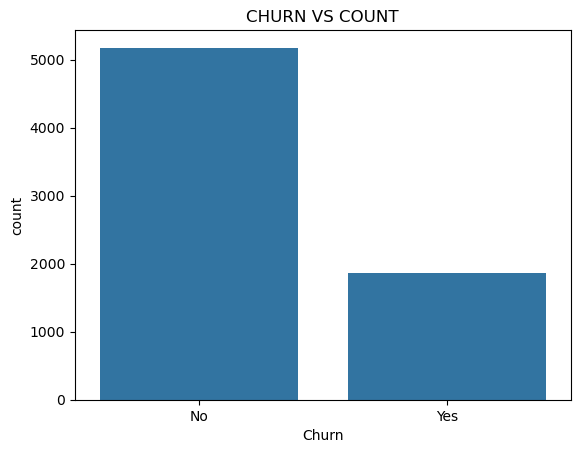

In [43]:
sns.countplot(data=df,x="Churn").set(title="CHURN VS COUNT")
#data was medium to  balance
#df["Churn"].value_counts().plot(kind="bar")

<Axes: xlabel='Contract', ylabel='count'>

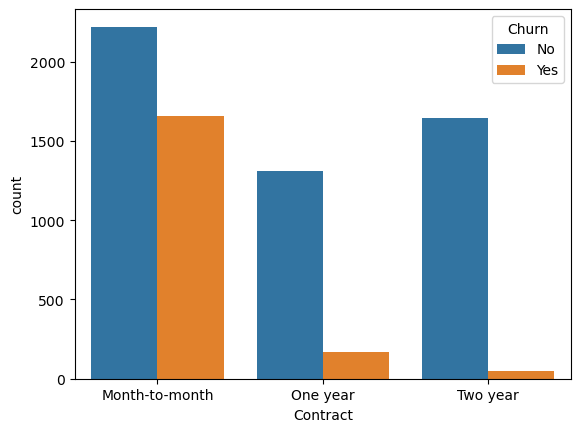

In [44]:
sns.countplot(x="Contract", hue="Churn",data=df)
#month to month contract type have high risk churn then other 
#cross_tab = pd.crosstab(df['Contract'], df['Churn'])
#cross_tab.plot(kind='bar')

<Axes: ylabel='TotalCharges'>

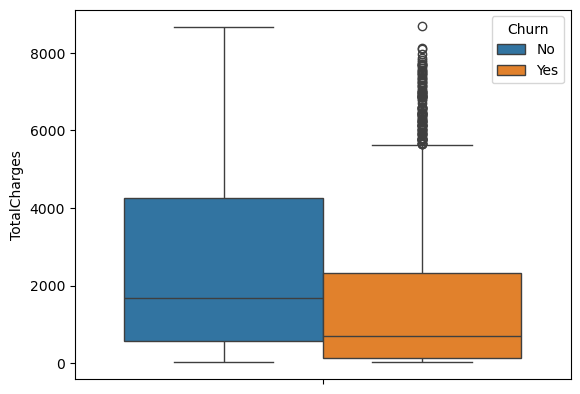

In [45]:
sns.boxplot(y=df["TotalCharges"],hue="Churn",data=df)
#those customer have less total charges high chance to churn 

<Axes: ylabel='MonthlyCharges'>

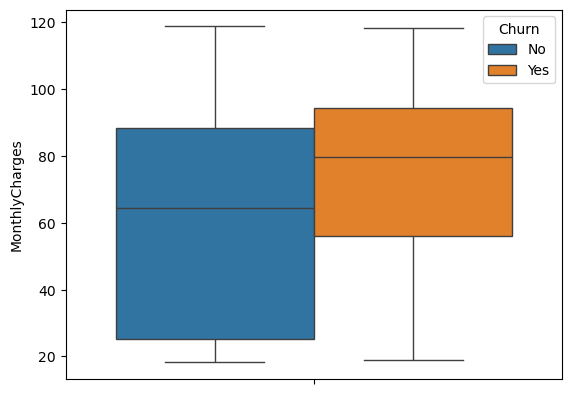

In [46]:
sns.boxplot(y=df["MonthlyCharges"],hue="Churn",data=df)
#those customers have high monthy charges that was high chance to churn

<Axes: ylabel='tenure'>

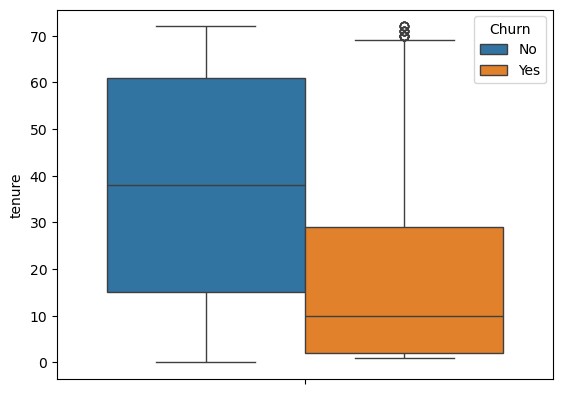

In [47]:
sns.boxplot(y=df["tenure"],hue="Churn",data=df)
#those cutomers have less tenure that was high chance to churn

<Axes: xlabel='gender', ylabel='count'>

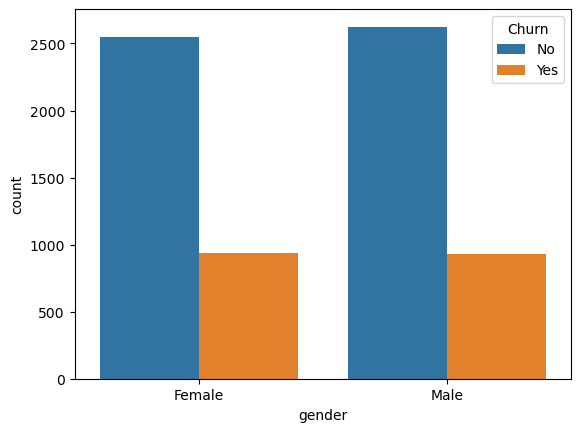

In [48]:
sns.countplot(x="gender", hue="Churn",data=df)
#both male female equal chance to churn

<Axes: xlabel='TechSupport', ylabel='count'>

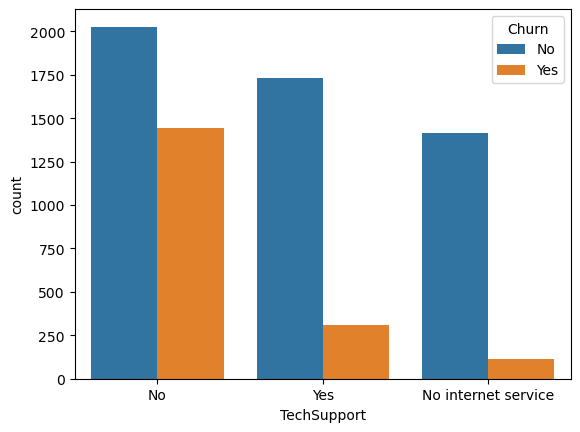

In [49]:
sns.countplot(x="TechSupport", hue="Churn",data=df)
#those customer have no tech support that was high chance to churn 
#and those customers have tech support slightly high chance to churn than no internet customers 

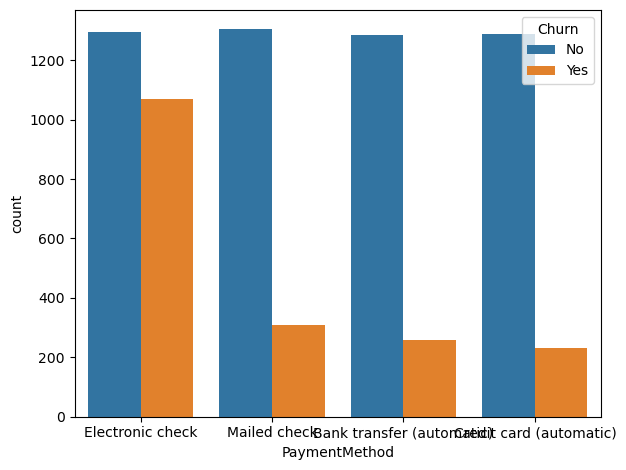

In [50]:
sns.countplot(x="PaymentMethod", hue="Churn",data=df)
plt.tight_layout()

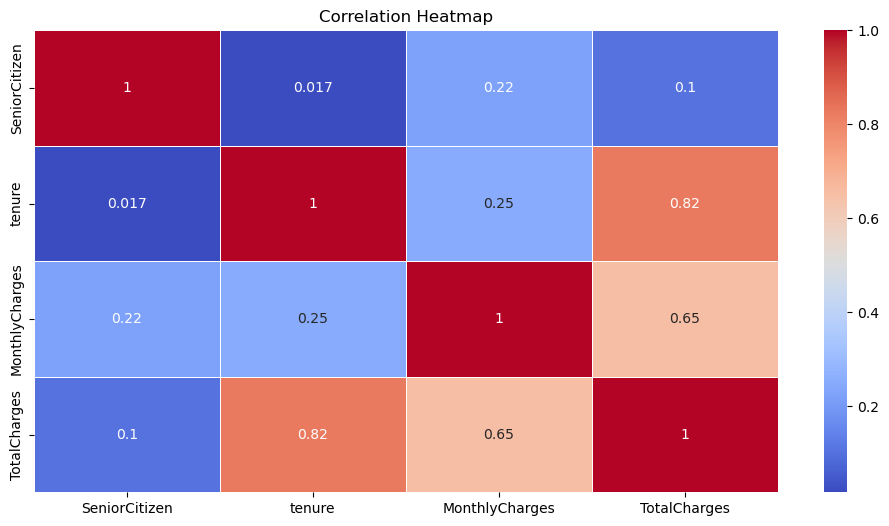

In [51]:
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering
## Data Preprocessing

Before training the models, the dataset required some preprocessing steps.

The following steps were performed:

- Removed unnecessary columns such as customerID
- Converted TotalCharges to numeric values
- Handled missing values
- Encoded categorical variables
- Scaled numerical features where necessary

In [119]:
df=df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
cat_cols= [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'PaperlessBilling', 'Churn',"InternetService","Contract","PaymentMethod"
]
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df = df.replace({
    'Yes':1,'No':0,
    'Male':1,'Female':0,
    'No internet service':0,
    'No phone service':0
}).infer_objects(copy=False)

cr= df.select_dtypes(include='number').corrwith(df['Churn'])
cr=cr.sort_values(ascending=False)
print(cr)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
gender             -0.008612
DeviceProtection   -0.066160
OnlineBackup       -0.082255
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
TotalCharges       -0.199428
tenure             -0.352229
dtype: float64


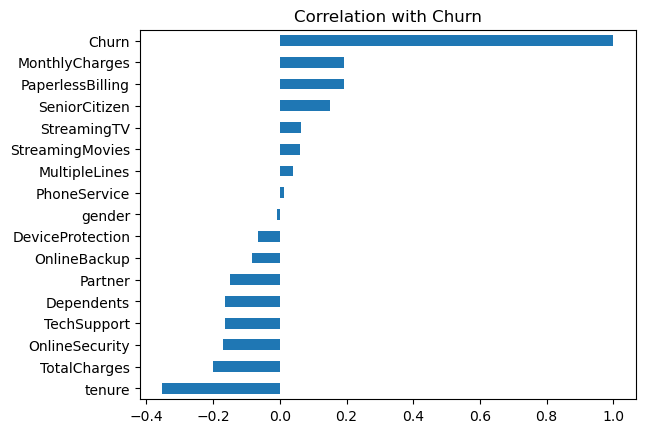

In [54]:
cr.sort_values().plot(kind="barh")
plt.title("Correlation with Churn")
plt.show()

In [60]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [102]:
cols=["InternetService","Contract","PaymentMethod"]
df=pd.get_dummies(df,columns=cols,drop_first=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,No,Yes,...,29.85,29.85,No,False,False,False,False,False,True,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Yes,No,...,56.95,1889.5,No,False,False,True,False,False,False,True
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Yes,Yes,...,53.85,108.15,Yes,False,False,False,False,False,False,True
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,Yes,No,...,42.30,1840.75,No,False,False,True,False,False,False,False
4,9237-HQITU,Female,0,No,No,2,Yes,No,No,No,...,70.70,151.65,Yes,True,False,False,False,False,True,False


In [63]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].mean())
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
InternetService_DSL                      0
InternetService_Fiber optic              0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

Train Test Split

In [64]:
x=df.drop("Churn", axis=1)
y=df["Churn"]

x_train , x_test , y_train , y_test= train_test_split  (
x , y,test_size=0.2, random_state=42)



In [65]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Multiple Model Train

## Model Training

Multiple machine learning models were trained to compare their performance.

The models used in this project include:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

Each model was trained using the training dataset and evaluated on the test dataset.

In [70]:
# 10 Define Models

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = []

# 11 Train and Evaluate Models

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    results.append([name, acc, precision, recall, f1, roc])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.821859   0.687117  0.600536  0.640916  0.751040
1        Decision Tree  0.716111   0.463612  0.461126  0.462366  0.634521
2        Random Forest  0.789922   0.645283  0.458445  0.536050  0.683856
3    Gradient Boosting  0.814762   0.686667  0.552279  0.612184  0.730773
4                  SVM  0.810504   0.684028  0.528150  0.596067  0.720156
5                  KNN  0.772889   0.579104  0.520107  0.548023  0.692003


## Hyperparameter Tunning

In [78]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
log_model = LogisticRegression()

grid_search = GridSearchCV(
    log_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)



Best Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}


## Model Evaluation

To evaluate model performance, the following metrics were used:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

These metrics help measure how well the model can correctly identify churn customers.


Accuracy: 0.7984386089425124
Precision: 0.6027713625866051
Recall: 0.6997319034852547
F1 Score: 0.6476426799007444
con_met: [[864 172]
 [112 261]]
ROC AUC: 0.7668543687310443


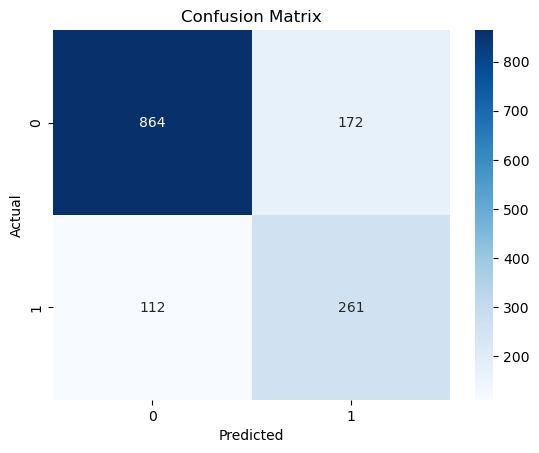

In [86]:
best_log_model = grid_search.best_estimator_
y_pred = best_log_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("con_met:", cm)
                      

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1036
           1       0.60      0.70      0.65       373

    accuracy                           0.80      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.80      0.80      1409

ROC AUC: 0.7668543687310443


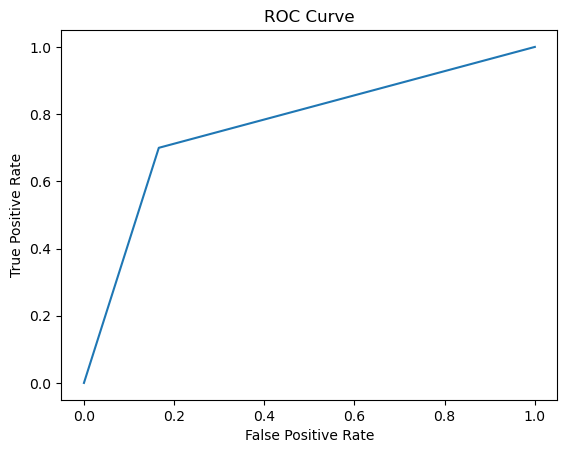

In [92]:
print(classification_report(y_test, y_pred))
roc = roc_auc_score(y_test, y_pred)
print("ROC AUC:", roc)

fpr, tpr, threshold = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Best Model

After comparing all models, **Logistic Regression performed the best** for this problem.

Performance results:

Accuracy ≈ 82%  
Precision ≈ 0.68  
Recall ≈ 0.60  
F1 Score ≈ 0.64  
ROC-AUC ≈ 0.75

This model provided a good balance between precision and recall when identifying churn customers.

## Cross-Validation

In [95]:
scores = cross_val_score(best_log_model, x_train, y_train, cv=5)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.7775994048866748


## Feature Importance


In [100]:
importance = best_log_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                                  Feature  Importance
17            InternetService_Fiber optic    0.102705
21         PaymentMethod_Electronic check    0.092416
14                         MonthlyCharges    0.072186
13                       PaperlessBilling    0.063238
1                           SeniorCitizen    0.044528
12                        StreamingMovies    0.029092
11                            StreamingTV    0.025170
6                           MultipleLines    0.014710
0                                  gender   -0.005293
5                            PhoneService   -0.012617
9                        DeviceProtection   -0.014524
16                    InternetService_DSL   -0.022640
8                            OnlineBackup   -0.024595
22             PaymentMethod_Mailed check   -0.029346
2                                 Partner   -0.035280
20  PaymentMethod_Credit card (automatic)   -0.035556
3                              Dependents   -0.043286
10                          

## Feature Importance

To understand what drives customer churn, feature importance analysis was performed.

Some of the most influential factors include:

- Contract type
- Monthly charges
- Tenure
- Internet service

These features play a key role in determining whether a customer is likely to leave the service.

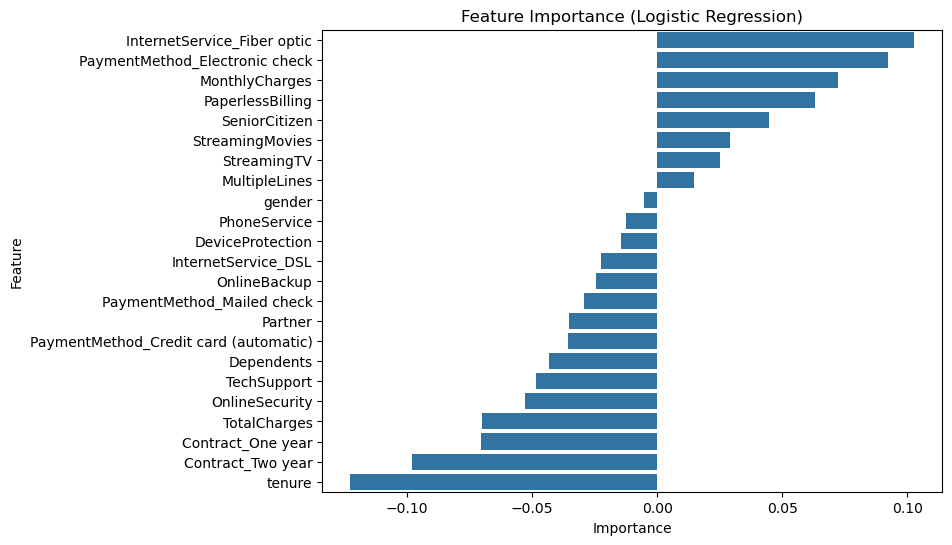

In [101]:


plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance (Logistic Regression)")
plt.show()

## Business Insights

The analysis suggests that customers with month-to-month contracts and higher monthly charges are more likely to churn.

Customers who have stayed longer with the company tend to remain loyal.

Based on these findings, telecom companies can reduce churn by:

- Encouraging long-term contracts
- Offering loyalty benefits
- Providing targeted offers to high-risk customers

## Conclusion

In this project, I built and evaluated several machine learning models to predict customer churn.

Among the tested models, Logistic Regression achieved the best overall performance.

This project demonstrates how machine learning can help businesses identify potential churn customers and take preventive actions to improve customer retention.